In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 10
RUN_FINE_TUNING = True

FINE_TUNE_LAST_N = 30

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))


KeyboardInterrupt: 

In [11]:
SPLIT_DIR = Path("./DATASET_SPLIT")
OUTPUT_DIR = Path("./training_outputs")
MODEL_DIR = OUTPUT_DIR / "saved_models"
PLOT_DIR = OUTPUT_DIR / "plots"

for d in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not SPLIT_DIR.exists():
    raise FileNotFoundError(
        f"{SPLIT_DIR.resolve()} not found. "
        "Run your preprocessing notebook first so DATASET_SPLIT is created."
    )

if (SPLIT_DIR / "train" / "LSD_Affected").exists():
    LSD_CLASS = "LSD_Affected"
elif (SPLIT_DIR / "train" / "LSD").exists():
    LSD_CLASS = "LSD"
else:
    raise FileNotFoundError("Could not find LSD_Affected or LSD inside DATASET_SPLIT/train.")

CLASS_NAMES = ["Healthy", LSD_CLASS]
NUM_CLASSES = 2

print("Classes:", CLASS_NAMES)
print("Split directory:", SPLIT_DIR.resolve())


Classes: ['Healthy', 'LSD_Affected']
Split directory: E:\LSD_DETECTION_XAI_PROJECT\DATASET_SPLIT


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "val",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class order:", train_ds.class_names)


Found 416 files belonging to 2 classes.
Found 82 files belonging to 2 classes.
Found 83 files belonging to 2 classes.
Class order: ['Healthy', 'LSD_Affected']


In [14]:
def count_split_images(split_name):
    counts = {}
    for class_name in CLASS_NAMES:
        folder = SPLIT_DIR / split_name / class_name
        counts[class_name] = sum(
            1 for p in folder.rglob("*")
            if p.is_file()
        )
    return counts

split_counts = pd.DataFrame({
    split: count_split_images(split)
    for split in ["train", "val", "test"]
}).T

display(split_counts)


,Healthy,LSD_Affected
train,227,227
val,49,48
test,49,49


In [16]:
from pathlib import Path
from PIL import Image

SPLIT_DIR = Path("./DATASET_SPLIT")

convert_extensions = {".webp", ".avif"}

converted = 0

for split in ["train", "val", "test"]:
    for class_dir in (SPLIT_DIR / split).iterdir():

        if not class_dir.is_dir():
            continue

        for img_path in list(class_dir.iterdir()):

            if img_path.suffix.lower() in convert_extensions:

                try:
                    with Image.open(img_path) as img:
                        img = img.convert("RGB")

                        new_path = img_path.with_suffix(".jpg")

                        # avoid overwriting
                        if new_path.exists():
                            new_path = img_path.with_name(
                                img_path.stem + "_converted.jpg"
                            )

                        img.save(
                            new_path,
                            "JPEG",
                            quality=95
                        )

                    img_path.unlink()
                    converted += 1

                except Exception as e:
                    print("Could not convert:", img_path, e)

print("Converted:", converted)

Converted: 68


In [ ]:

train_ds_for_weights = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

y_train = np.concatenate([
    labels.numpy().reshape(-1).astype(int)
    for _, labels in train_ds_for_weights
])

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", CLASS_WEIGHTS)

del train_ds_for_weights, y_train
gc.collect()


Found 454 files belonging to 2 classes.


Class weights: {0: 1.0, 1: 1.0}


234

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="data_augmentation")


In [ ]:


def preprocess_for_model(model_name, images):
    images = tf.cast(images, tf.float32)

    if model_name == "EfficientNetB0":
        return images

    if model_name == "MobileNetV2":
        return tf.keras.applications.mobilenet_v2.preprocess_input(images)

    if model_name == "ResNet50":
        return tf.keras.applications.resnet50.preprocess_input(images)

    if model_name == "VGG16":
        return tf.keras.applications.vgg16.preprocess_input(images)

    raise ValueError(f"Unknown model: {model_name}")


def make_datasets_for_model(model_name):
    def train_map(images, labels):
        images = data_augmentation(images, training=True)
        images = preprocess_for_model(model_name, images)
        return images, labels

    def eval_map(images, labels):
        images = preprocess_for_model(model_name, images)
        return images, labels

    train_ready = train_ds.map(train_map, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ready = val_ds.map(eval_map, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
    test_ready = test_ds.map(eval_map, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

    return train_ready, val_ready, test_ready


In [20]:
def get_backbone(model_name):
    if model_name == "EfficientNetB0":
        return tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=IMG_SIZE + (3,),
            pooling="avg"
        )

    if model_name == "MobileNetV2":
        return tf.keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=IMG_SIZE + (3,),
            pooling="avg"
        )

    if model_name == "ResNet50":
        return tf.keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=IMG_SIZE + (3,),
            pooling="avg"
        )

    if model_name == "VGG16":
        return tf.keras.applications.VGG16(
            include_top=False,
            weights="imagenet",
            input_shape=IMG_SIZE + (3,),
            pooling="avg"
        )

    raise ValueError(f"Unknown model: {model_name}")


def build_model(model_name):
    backbone = get_backbone(model_name)
    backbone.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,), name="image")
    x = backbone(inputs, training=False)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    model = keras.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model, backbone


In [21]:
def make_callbacks(model_name, phase="initial"):
    checkpoint_path = MODEL_DIR / f"{model_name}_{phase}_best.keras"

    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            str(OUTPUT_DIR / f"{model_name}_{phase}_history.csv")
        )
    ]


In [ ]:
def unfreeze_last_layers(backbone, last_n=30):
    backbone.trainable = True

    for layer in backbone.layers[:-last_n]:
        layer.trainable = False

    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def compile_for_finetuning(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )


In [ ]:
MODEL_NAMES = [
    "EfficientNetB0",
    "MobileNetV2",
    "ResNet50",
    "VGG16"
]


def train_one_model(model_name):
    print("\n" + "=" * 80)
    print(f"TRAINING: {model_name}")
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()

    train_ready, val_ready, test_ready = make_datasets_for_model(model_name)
    model, backbone = build_model(model_name)

    print("\nModel summary:")
    model.summary()

    start_time = time.time()


    print(f"\n--- {model_name}: Initial transfer learning ---")
    history_initial = model.fit(
        train_ready,
        validation_data=val_ready,
        epochs=INITIAL_EPOCHS,
        class_weight=CLASS_WEIGHTS,
        callbacks=make_callbacks(model_name, "initial"),
        verbose=1
    )

    history_all = dict(history_initial.history)


    if RUN_FINE_TUNING:
        print(f"\n--- {model_name}: Fine-tuning last {FINE_TUNE_LAST_N} backbone layers ---")

        unfreeze_last_layers(backbone, FINE_TUNE_LAST_N)
        compile_for_finetuning(model)

        history_ft = model.fit(
            train_ready,
            validation_data=val_ready,
            epochs=FINE_TUNE_EPOCHS,
            class_weight=CLASS_WEIGHTS,
            callbacks=make_callbacks(model_name, "finetune"),
            verbose=1
        )

        for key, values in history_ft.history.items():
            history_all.setdefault(key, [])
            history_all[key].extend(values)

    # Load the best fine-tuned model if it exists; otherwise use initial best.
    best_ft = MODEL_DIR / f"{model_name}_finetune_best.keras"
    best_initial = MODEL_DIR / f"{model_name}_initial_best.keras"

    if RUN_FINE_TUNING and best_ft.exists():
        model = keras.models.load_model(best_ft)
    elif best_initial.exists():
        model = keras.models.load_model(best_initial)

    # Final test evaluation
    test_metrics = model.evaluate(test_ready, verbose=0, return_dict=True)

    y_true = []
    y_prob = []

    for images, labels in test_ready:
        probs = model.predict(images, verbose=0).reshape(-1)
        y_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().reshape(-1).astype(int).tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob),
        "Test Loss": float(test_metrics["loss"]),
        "Training Time (min)": (time.time() - start_time) / 60.0
    }

    print("\nTest metrics:")
    print(pd.Series(metrics))

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    pred_df = pd.DataFrame({
        "True_Label": y_true,
        "True_Class": [CLASS_NAMES[i] for i in y_true],
        "Predicted_Label": y_pred,
        "Predicted_Class": [CLASS_NAMES[i] for i in y_pred],
        "LSD_Probability": y_prob
    })
    pred_df.to_csv(
        OUTPUT_DIR / f"{model_name}_test_predictions.csv",
        index=False
    )

    final_model_path = MODEL_DIR / f"{model_name}_best.keras"
    model.save(final_model_path)

    return {
        "model_name": model_name,
        "model": model,
        "history": history_all,
        "metrics": metrics,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "cm": cm
    }


In [ ]:

all_results = {}

for name in MODEL_NAMES:
    try:
        all_results[name] = train_one_model(name)
    except Exception as e:
        print(f"\n❌ {name} failed: {e}")
        print("Continuing with the next model...")
        tf.keras.backend.clear_session()
        gc.collect()

print("\nCompleted models:", list(all_results.keys()))



TRAINING: EfficientNetB0

Model summary:


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

...

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


--- VGG16: Initial transfer learning ---
Epoch 1/15


c:\Users\emran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6611 - auc: 0.7027 - loss: 1.6504 - precision: 0.6561 - recall: 0.6200
Epoch 1: val_auc improved from None to 0.91118, saving model to training_outputs\saved_models\VGG16_initial_best.keras

Epoch 1: finished saving model to training_outputs\saved_models\VGG16_initial_best.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - accuracy: 0.6611 - auc: 0.7027 - loss: 1.6504 - precision: 0.6561 - recall: 0.6200 - val_accuracy: 0.7927 - val_auc: 0.9112 - val_loss: 0.7710 - val_precision: 0.7234 - val_recall: 0.8947 - learning_rate: 0.0010
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7885 - auc: 0.8432 - loss: 1.0247 - precision: 0.7692 - recall: 0.8000
Epoch 2: val_auc improved from 0.91118 to 0.94767, saving model to training_outputs\saved_models\VGG16_initial_best.keras

Epoch 2: finished saving model to training_outputs\saved_models\VGG16_initial_best.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.7885 - auc: 0.84

,Model,Accuracy,Precision,Recall,F1,AUC,Test Loss,Training Time (min)
0,ResNet50,0.879518,0.916667,0.825,0.868421,0.950581,0.383961,9.195729
1,MobileNetV2,0.867470,0.871795,0.850,0.860759,0.956977,0.317674,3.268582
2,EfficientNetB0,0.855422,0.818182,0.900,0.857143,0.950000,0.350491,5.192140
3,VGG16,0.843373,0.935484,0.725,0.816901,0.930233,0.429354,50.747075


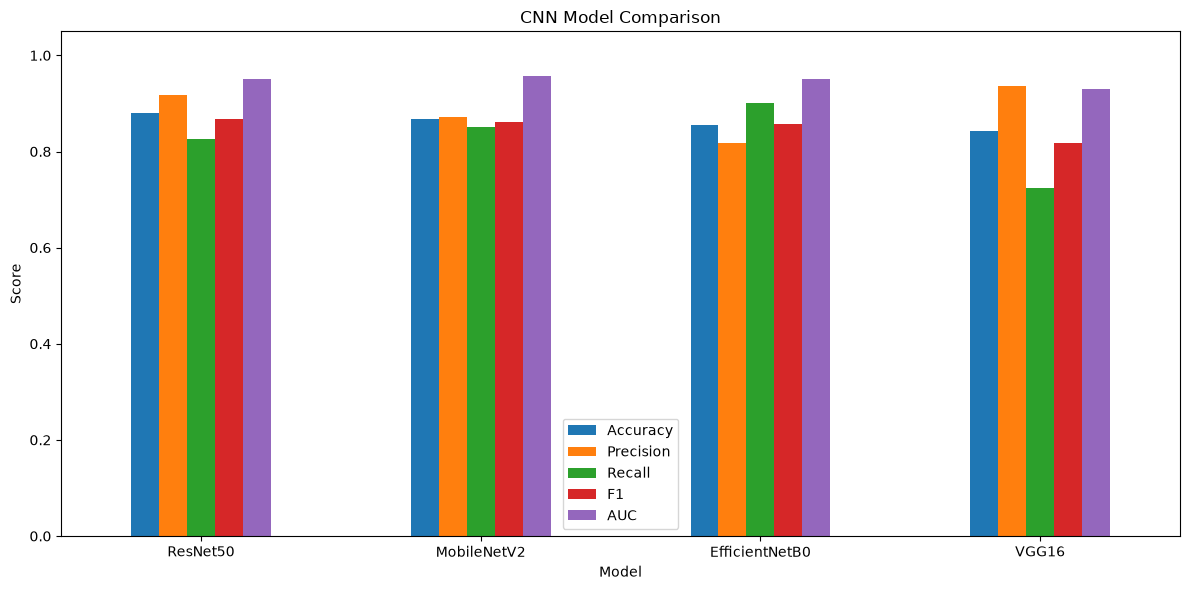

In [ ]:
if not all_results:
    raise RuntimeError("No model completed successfully.")

results_df = pd.DataFrame([
    result["metrics"]
    for result in all_results.values()
]).sort_values("F1", ascending=False).reset_index(drop=True)

display(results_df)

results_df.to_csv(
    OUTPUT_DIR / "model_comparison_results.csv",
    index=False
)

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

ax = results_df.set_index("Model")[metric_cols].plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("CNN Model Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / "model_comparison_metrics.png", dpi=200)
plt.show()


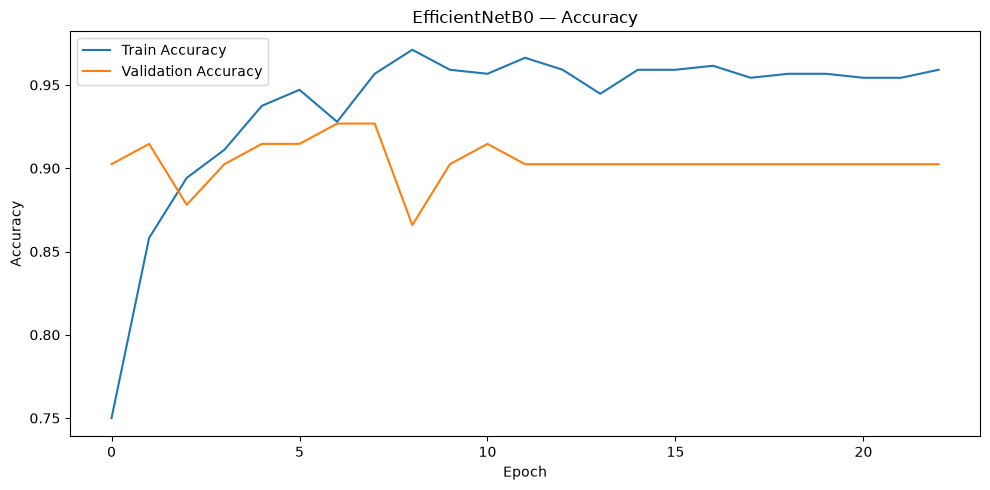

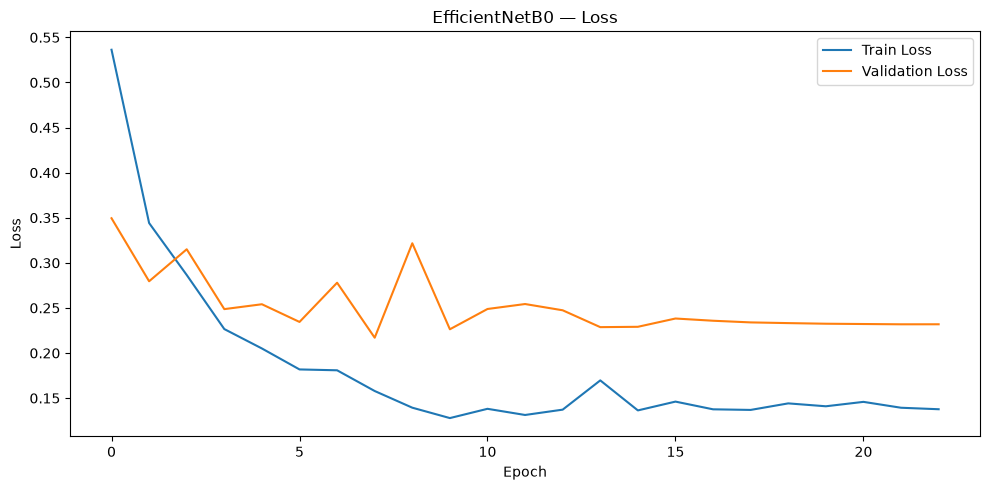

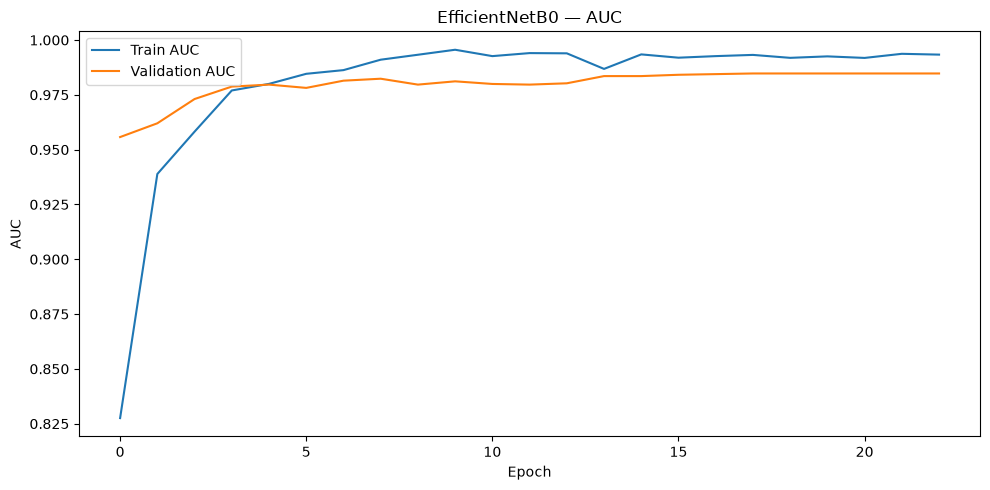

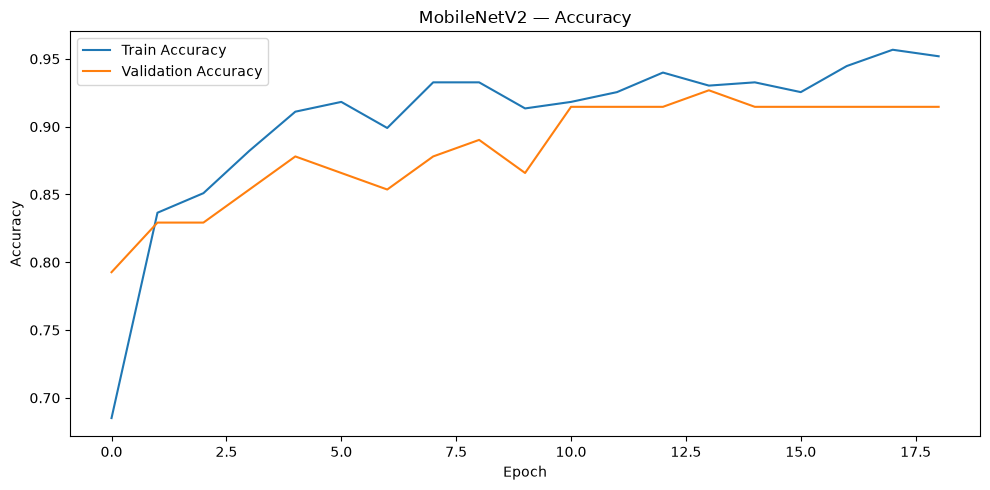

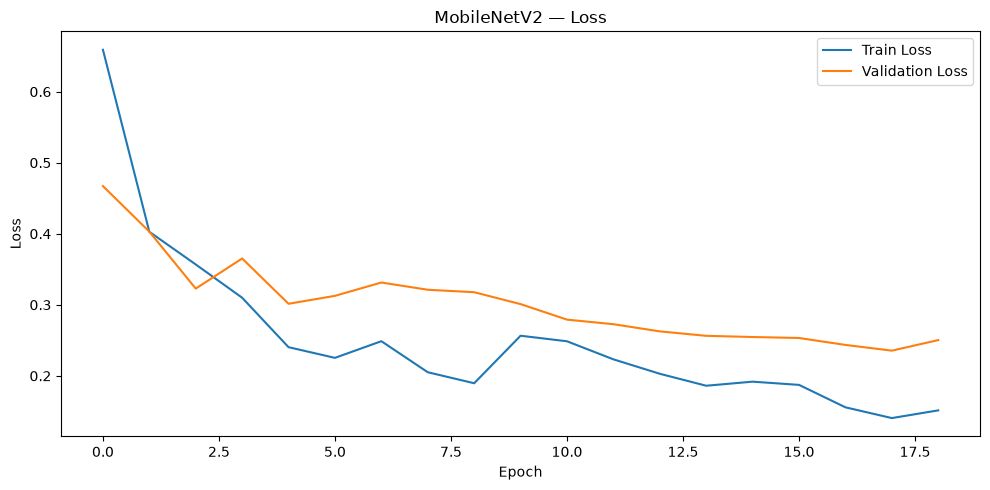

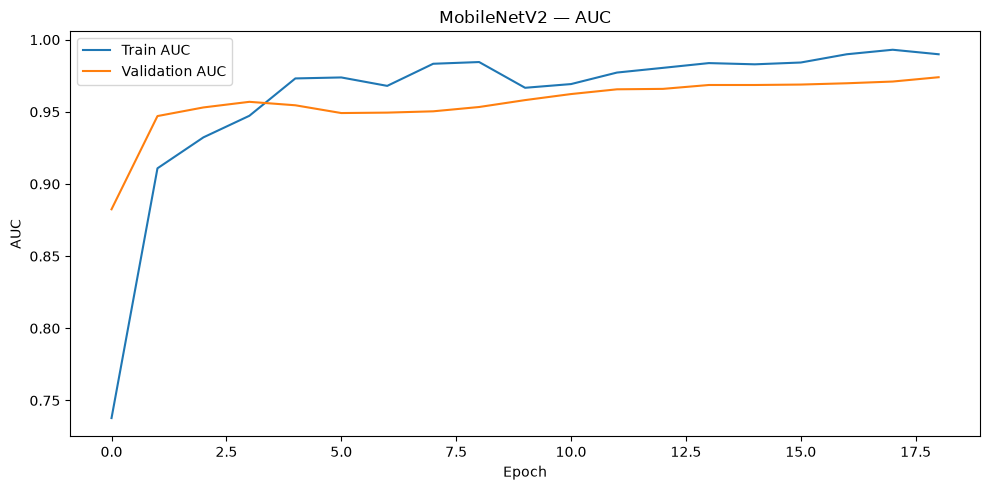

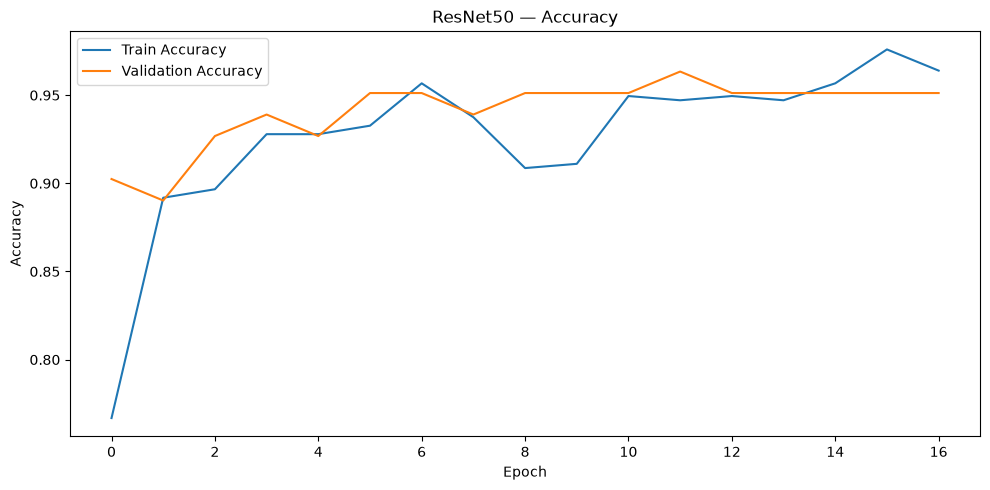

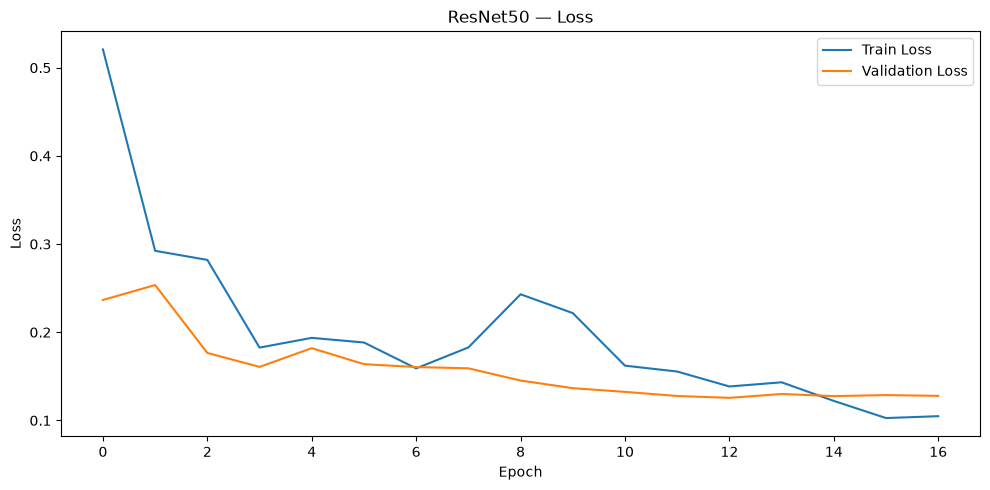

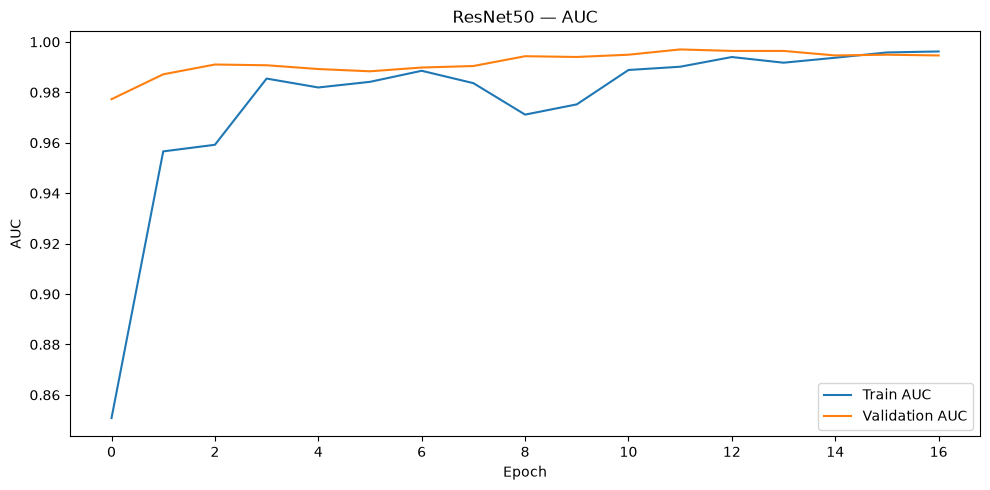

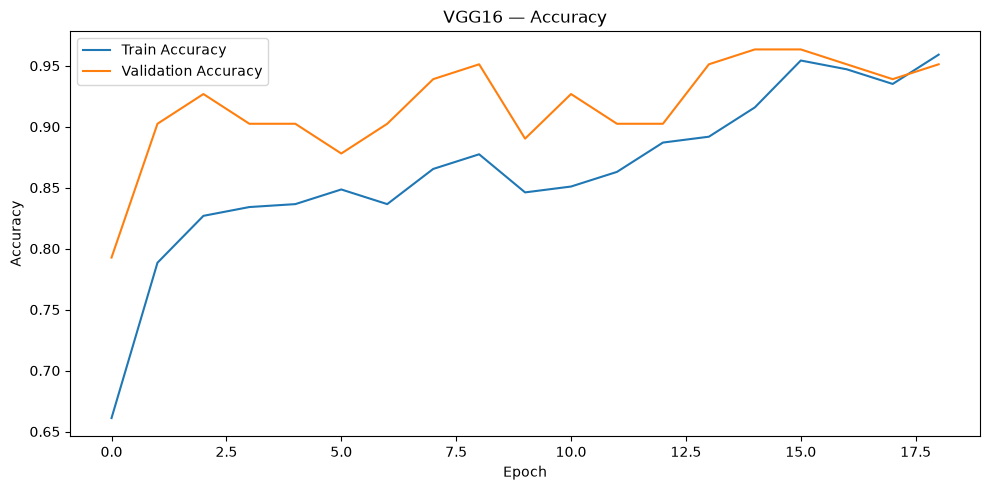

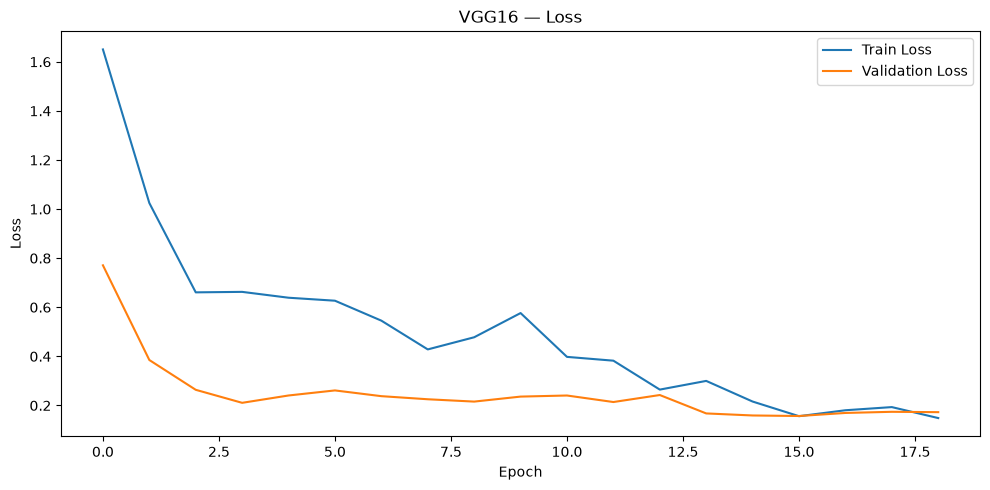

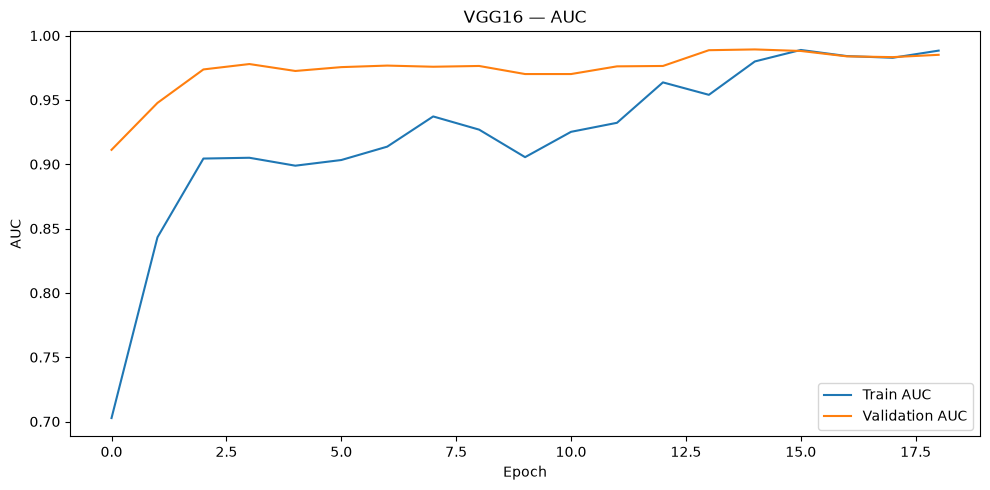

In [27]:
def plot_history(model_name, history):
    history_df = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history_df["accuracy"], label="Train Accuracy")
    ax.plot(history_df["val_accuracy"], label="Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{model_name} — Accuracy")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{model_name}_accuracy.png", dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history_df["loss"], label="Train Loss")
    ax.plot(history_df["val_loss"], label="Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{model_name} — Loss")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{model_name}_loss.png", dpi=200)
    plt.show()

    if "auc" in history_df.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(history_df["auc"], label="Train AUC")
        ax.plot(history_df["val_auc"], label="Validation AUC")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("AUC")
        ax.set_title(f"{model_name} — AUC")
        ax.legend()
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"{model_name}_auc.png", dpi=200)
        plt.show()


for name, result in all_results.items():
    plot_history(name, result["history"])


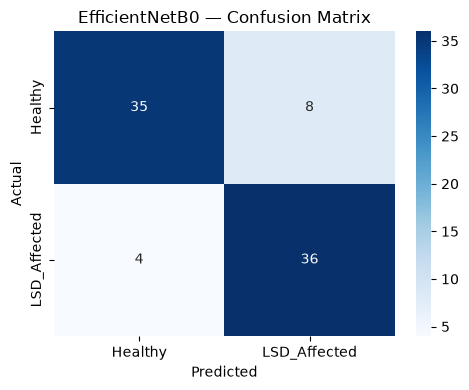

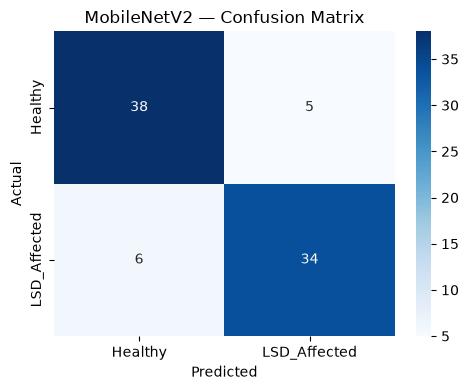

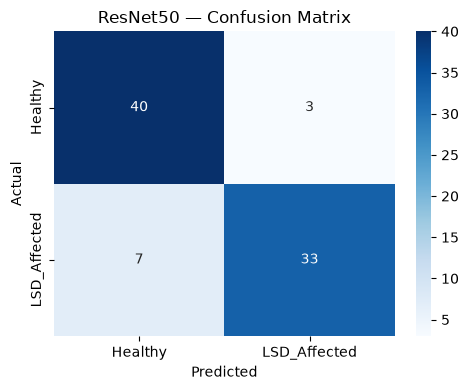

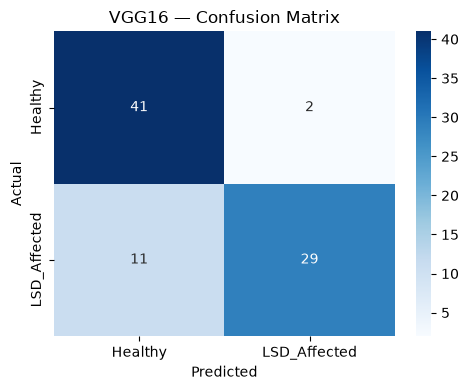

In [28]:
for name, result in all_results.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        result["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{name}_confusion_matrix.png", dpi=200)
    plt.show()


In [29]:
best_row = results_df.iloc[0]
best_name = best_row["Model"]

print(f"Best model by F1 score: {best_name}")
display(best_row.to_frame(name="Value"))


Best model by F1 score: ResNet50


,Value
Model,ResNet50
Accuracy,0.879518
Precision,0.916667
Recall,0.825
F1,0.868421
AUC,0.950581
Test Loss,0.383961
Training Time (min),9.195729


In [30]:
report = {
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "initial_epochs": INITIAL_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "fine_tuning_enabled": RUN_FINE_TUNING,
    "fine_tune_last_n": FINE_TUNE_LAST_N,
    "class_names": CLASS_NAMES,
    "class_weights": CLASS_WEIGHTS,
    "models_completed": list(all_results.keys()),
    "best_model_by_f1": best_name,
}

with open(OUTPUT_DIR / "training_config_and_summary.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Saved:")
print(" -", OUTPUT_DIR / "model_comparison_results.csv")
print(" -", OUTPUT_DIR / "training_config_and_summary.json")
print(" -", MODEL_DIR)
print(" -", PLOT_DIR)


Saved:
 - training_outputs\model_comparison_results.csv
 - training_outputs\training_config_and_summary.json
 - training_outputs\saved_models
 - training_outputs\plots
